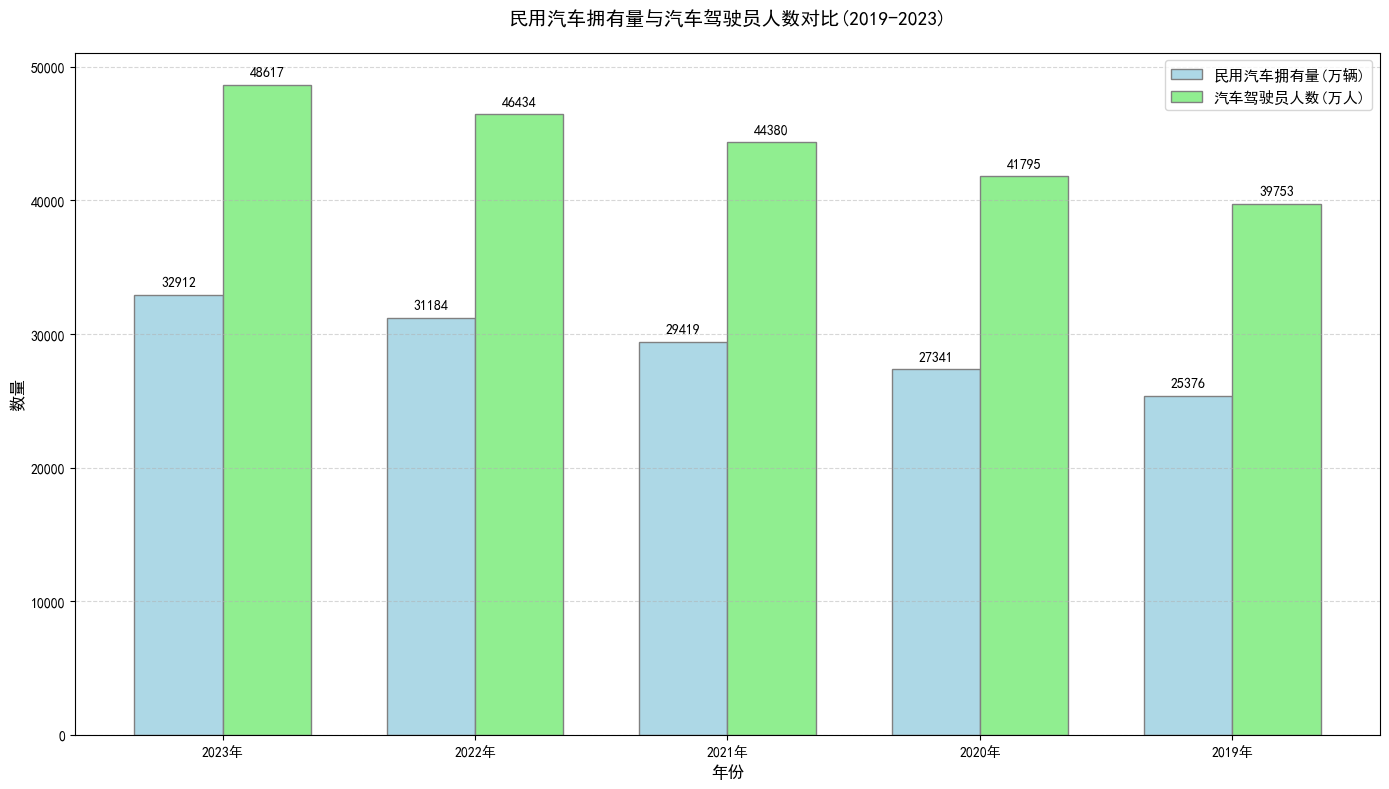

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
data = pd.read_csv('年度数据.csv')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建画布
plt.figure(figsize=(14, 8))

# 设置x轴位置
years = data['指标']
x = np.arange(len(years))
width = 0.35  # 柱状图宽度

# 定义颜色 - 使用淡蓝色和淡绿色
light_blue = '#ADD8E6'  # 淡蓝色
light_green = '#90EE90' # 淡绿色

# 绘制民用汽车拥有量条形图（淡蓝色）
plt.bar(x - width/2, data['民用汽车拥有量(万辆)'], width, 
        label='民用汽车拥有量(万辆)', color=light_blue, edgecolor='gray')

# 绘制汽车驾驶员人数条形图（淡绿色）
plt.bar(x + width/2, data['汽车驾驶员人数(万人)'], width, 
        label='汽车驾驶员人数(万人)', color=light_green, edgecolor='gray')

# 添加标签和标题
plt.xlabel('年份', fontsize=12)
plt.ylabel('数量', fontsize=12)
plt.title('民用汽车拥有量与汽车驾驶员人数对比(2019-2023)', fontsize=14, pad=20)
plt.xticks(x, years, fontsize=10)
plt.legend(fontsize=11)

# 在柱子上方显示数值
for i in x:
    plt.text(i - width/2, data['民用汽车拥有量(万辆)'][i] + 500, 
             f"{data['民用汽车拥有量(万辆)'][i]:.0f}", 
             ha='center', va='bottom', fontsize=10)
    plt.text(i + width/2, data['汽车驾驶员人数(万人)'][i] + 500, 
             f"{data['汽车驾驶员人数(万人)'][i]:.0f}", 
             ha='center', va='bottom', fontsize=10)

# 调整布局
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 显示图表
plt.show()


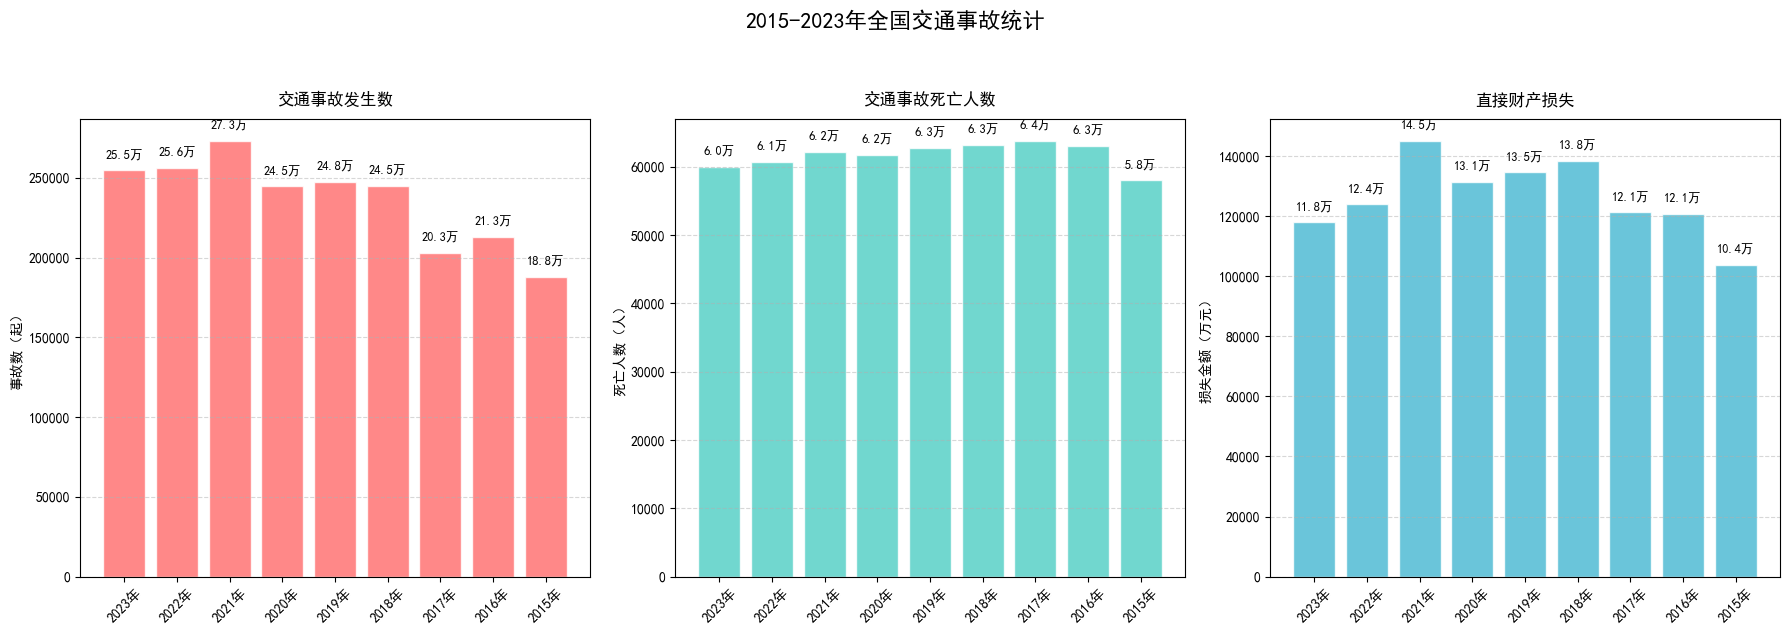

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取数据
data = pd.read_csv('年度数据2.csv')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建画布和子图（1行3列）
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('2015-2023年全国交通事故统计', fontsize=16, y=1.05)

# 颜色设置
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # 红/青/蓝

# 子图1：交通事故发生数
axes[0].bar(data['指标'], data['交通事故发生数总计(起)'], 
           color=colors[0], edgecolor='white', alpha=0.8)
axes[0].set_title('交通事故发生数', pad=10)
axes[0].set_ylabel('事故数（起）')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 子图2：交通事故死亡人数
axes[1].bar(data['指标'], data['交通事故死亡人数总计(人)'], 
           color=colors[1], edgecolor='white', alpha=0.8)
axes[1].set_title('交通事故死亡人数', pad=10)
axes[1].set_ylabel('死亡人数（人）')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# 子图3：直接财产损失
axes[2].bar(data['指标'], data['交通事故直接财产损失总计(万元)'], 
           color=colors[2], edgecolor='white', alpha=0.8)
axes[2].set_title('直接财产损失', pad=10)
axes[2].set_ylabel('损失金额（万元）')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    y_max = ax.get_ylim()[1]  # 获取当前子图的y轴最大值
    dynamic_offset = y_max * 0.02  # 自动计算2%的偏移量
    
    for i, v in enumerate(ax.containers[0]):
        height = v.get_height()
        ax.text(v.get_x() + v.get_width()/2, 
               height + dynamic_offset,
               f"{height/10000:.1f}万" if height > 10000 else f"{height:.0f}",
               ha='center', 
               va='bottom',
               fontsize=9)



# 调整布局
plt.tight_layout()

# 显示图表
plt.show()


In [3]:
import pandas as pd
import pygal
from pygal.style import Style

# 读取数据
try:
    data = pd.read_csv('年度数据.csv')
except FileNotFoundError:
    print("错误: '年度数据.csv' 文件未找到。请确保文件在正确的路径下。")
    exit()

# 提取数据
years = data['指标'].tolist()
car_ownership = data['民用汽车拥有量(万辆)'].tolist()
driver_population = data['汽车驾驶员人数(万人)'].tolist()

# 定义颜色 (Pygal 使用十六进制颜色码)
light_blue = '#ADD8E6'  # 淡蓝色
light_green = '#90EE90' # 淡绿色

# 创建自定义样式
# Pygal 对中文字体的处理依赖于最终渲染 SVG 的环境（如浏览器）是否安装了相应字体。
# 通常情况下，现代浏览器能很好地处理 SVG 中的中文字符。
# 如果需要特定字体，可以在 Style 中尝试设置，但这并非总是直接生效，取决于 SVG 查看器。
custom_style = Style(
    background='transparent',  # 图表背景色
    plot_background='transparent',  # 绘图区域背景色
    foreground='#333333',        # 坐标轴、标签等前景色
    foreground_strong='#333333', # 标题等更强的前景色
    foreground_subtle='#666666', # 辅助线等次要前景色
    opacity='.8',
    opacity_hover='.95',
    transition='400ms ease-in',
    colors=(light_blue, light_green), # 系列颜色
    title_font_size=20,         # 调整标题字体大小
    legend_font_size=14,        # 图例字体大小
    tooltip_font_size=12,       # 提示框字体大小
    value_font_size=10,         # 在柱子上显示数值的字体大小
    major_label_font_size=12,   # 主要刻度标签字体大小 (如 x_labels)
    label_font_size=14,         # 轴标题字体大小 (x_title, y_title)
    font_family='"SimHei", "Microsoft YaHei", sans-serif' # 尝试指定中文字体
)

# 创建分组柱状图对象
# Pygal 的 Bar chart 默认就是分组柱状图
bar_chart = pygal.Bar(
    width=1120,  # 图表宽度 (对应 Matplotlib figsize (14, _) * 80 dpi)
    height=640, # 图表高度 (对应 Matplotlib figsize (_, 8) * 80 dpi)
    style=custom_style,
    title='民用汽车拥有量与汽车驾驶员人数对比(2019-2023)',
    x_labels=years,           # X轴刻度标签 (年份)
    x_title='年份',
    y_title='数量',
    legend_at_bottom=True,    # 将图例放在底部
    legend_box_size=16,       # 图例标记大小
    print_values=True,


SyntaxError: incomplete input (50547413.py, line 56)

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Heiti TC' not found.
findfont: 

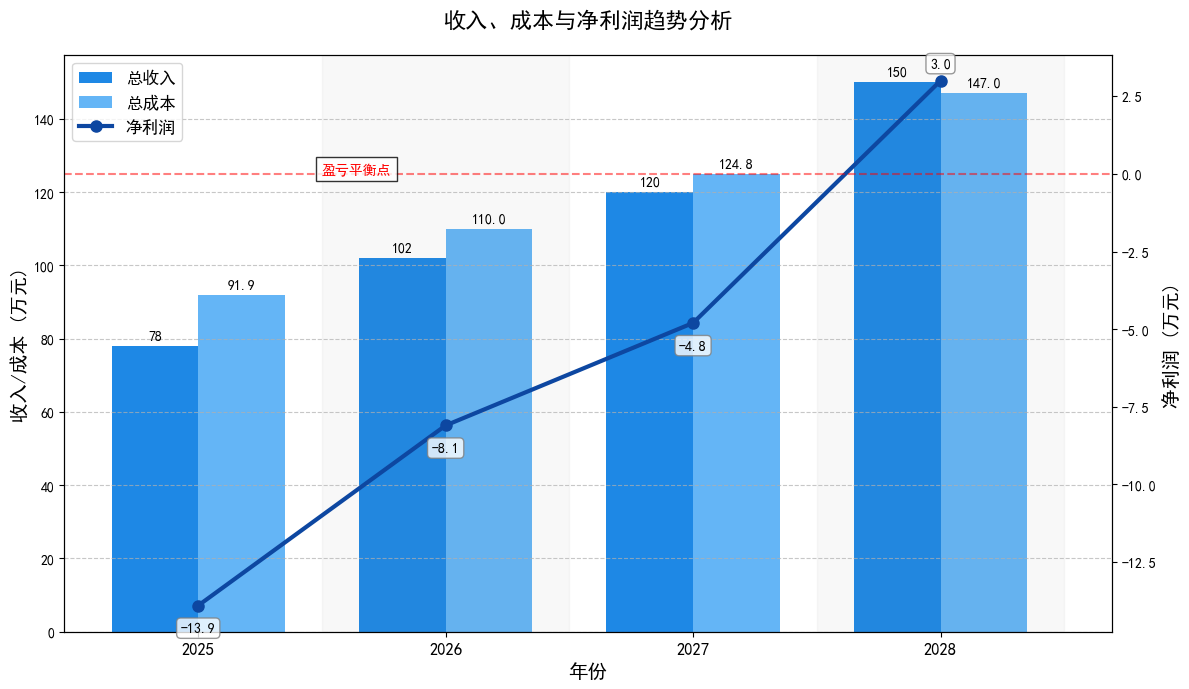

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 数据整理
data = {
    '年份': [2025, 2026, 2027, 2028],
    '总收入': [78, 102, 120, 150],
    '总成本': [91.9, 110, 124.8, 147],
    '净利润': [-13.9, -8.1, -4.8, 3]
}
df = pd.DataFrame(data).set_index('年份')

# 创建画布和双Y坐标轴
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

# 设置蓝色风格调色板
blue_palette = {
    '总收入': '#1E88E5',  # 主蓝色
    '总成本': '#64B5F6',  # 浅蓝
    '净利润': '#0D47A1'   # 深蓝
}

# 绘制柱状图（收入和成本）
x = np.arange(len(df.index))
width = 0.35
bar1 = ax1.bar(x - width/2, df['总收入'], width, label='总收入', color=blue_palette['总收入'])
bar2 = ax1.bar(x + width/2, df['总成本'], width, label='总成本', color=blue_palette['总成本'])

# 绘制折线图（净利润）
line = ax2.plot(x, df['净利润'], label='净利润', color=blue_palette['净利润'], 
                marker='o', markersize=8, linewidth=3)

# 设置坐标轴标签和标题
ax1.set_xlabel('年份', fontsize=14)
ax1.set_ylabel('收入/成本 (万元)', fontsize=14)
ax2.set_ylabel('净利润 (万元)', fontsize=14)
plt.title('收入、成本与净利润趋势分析', fontsize=16, pad=20)

# 设置x轴刻度和标签
ax1.set_xticks(x)
ax1.set_xticklabels(df.index, fontsize=12)

# 添加数据标签
def add_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

add_labels(bar1, ax1)
add_labels(bar2, ax1)

# 为折线图添加数据标签
for x_val, y_val in zip(x, df['净利润']):
    ax2.annotate(f'{y_val}',
                xy=(x_val, y_val),
                xytext=(0, 8 if y_val >= 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom' if y_val >= 0 else 'top',
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# 添加网格线
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 合并图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=12)

# 添加背景色区分不同年份
for i, year in enumerate(df.index):
    if i % 2 == 1:
        ax1.axvspan(i - 0.5, i + 0.5, alpha=0.05, color='gray')

# 添加盈亏平衡点参考线
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.text(0.5, 0, '盈亏平衡点', color='red', fontsize=10, 
        bbox=dict(facecolor='white', alpha=0.8))

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()